<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab07_FT/blob/develop/SEMANA_7_REGRESI%C3%93N_LOG%C3%8DSTICA_M%C3%81QUINAS_DE_VECTOR_DE_SOPORTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 7: REGRESIÓN LOGÍSTICA. MÁQUINAS DE VECTOR DE SOPORTE**

Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository
(https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando
las librerías de Python que se indican, haga lo siguiente

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
columnas = ['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion',
            'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
# Limpieza de datos
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df['Bare_nuclei'] = df['Bare_nuclei'].astype(int)
df.drop(columns=['Sample_code_number'], inplace=True)
df['Class'] = df['Class'].map({2: 0, 4: 1})  # 0: benigno, 1: maligno

In [ ]:
df.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


### **Codigo de funciones**

In [ ]:
def get_data_from_url(url):
    '''
    Retrieve data from a csv into a dataframe.
    input:
     - url: URL of the csv file
    output:
     - dataframe
    '''
    return pd.read_csv(url)

In [ ]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
df = get_data_from_url(URL)
df.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [ ]:
def clean_data(df):
    '''
    Clean the dataframe.
    input:
     - df: dataframe
    output:
     - dataframe
    '''
    df.replace('?', np.nan)
    return df

## **a. Calcule el information value (IV), tanto para el grupo de variable numéricas como categóricas y excluya las que tenga un poder predictivo débil o menor. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos**

In [ ]:
# Función para calcular WoE e IV
def calculate_woe_iv(df, feature, target):
    lst = []
    for val in df[feature].unique():
        total = df[df[feature] == val].count()[feature]
        good = df[(df[feature] == val) & (df[target] == 0)].count()[feature]
        bad = df[(df[feature] == val) & (df[target] == 1)].count()[feature]
        lst.append([val, total, good, bad])

    data = pd.DataFrame(lst, columns=['Value', 'Total', 'Good', 'Bad'])
    data['Distr_Good'] = data['Good'] / data['Good'].sum()
    data['Distr_Bad'] = data['Bad'] / data['Bad'].sum()
    data['WoE'] = np.log(data['Distr_Good'] / data['Distr_Bad']).replace([np.inf, -np.inf], 0)
    data['IV'] = (data['Distr_Good'] - data['Distr_Bad']) * data['WoE']
    return data['IV'].sum()

In [ ]:
# Calcular IV para cada variable
iv_values = {}
for col in df.columns[:-1]:  # Excluye 'Class'
    iv_values[col] = calculate_woe_iv(df, col, 'Class')

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = geta

In [ ]:
# Mostrar IV y filtrar las variables con IV > 0.02 (umbral común)
iv_df = pd.DataFrame.from_dict(iv_values, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)
print(iv_df)

                                   IV
Uniformity_of_cell_shape     5.290828
Bare_nuclei                  4.903711
Uniformity_of_cell_size      4.189561
Single_epithelial_cell_size  4.159839
Bland_chromatin              3.476306
Marginal_adhesion            2.915431
Normal_nucleoli              2.270390
Clump_thickness              2.259355
Mitoses                      1.026203


In [ ]:
# Filtrar variables con poder predictivo débil (IV < 0.02)
selected_features = iv_df[iv_df['IV'] > 0.02].index.tolist()
X = df[selected_features]
y = df['Class']

In [ ]:
# Dividir en datos de entrenamiento y prueba (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **b. Genere el modelo de regresión logística y evalúe la exclusión de variables mediante la significancia de los coeficientes. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Entrenar modelo de regresión logística
modelo_lr = LogisticRegression(max_iter=1000, solver='liblinear')
modelo_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
# Predicciones
y_pred_lr = modelo_lr.predict(X_test)

In [ ]:
# Métricas de clasificación
print("=== Clasificación - Regresión Logística ===")
print(classification_report(y_test, y_pred_lr))

=== Clasificación - Regresión Logística ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       103
           1       0.98      0.88      0.93        68

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



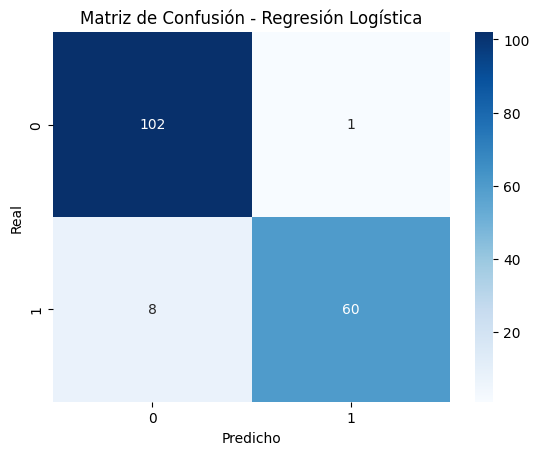

In [ ]:
# Matriz de confusión
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

In [ ]:
# Verificar importancia de los coeficientes
importancia = pd.Series(modelo_lr.coef_[0], index=X_train.columns)
print("Coeficientes del modelo:\n", importancia.sort_values(ascending=False))

Coeficientes del modelo:
 Bare_nuclei                    0.375764
Uniformity_of_cell_shape       0.279754
Uniformity_of_cell_size        0.193769
Normal_nucleoli                0.180561
Clump_thickness                0.168685
Bland_chromatin                0.160814
Marginal_adhesion              0.133627
Mitoses                        0.131707
Single_epithelial_cell_size   -0.155451
dtype: float64


## **c. Genere el modelo SVM, calcule sus métricas de clasificación y compárelas con las del modelo de regresión logística para ver si hubo o no mejoras.**

In [ ]:
from sklearn.svm import SVC

In [ ]:
# Entrenar modelo SVM
modelo_svm = SVC(kernel='rbf', C=1, gamma='scale')
modelo_svm.fit(X_train, y_train)

SVC(C=1)

In [ ]:
# Predicciones
y_pred_svm = modelo_svm.predict(X_test)

In [ ]:
# Métricas de clasificación
print("=== Clasificación - SVM ===")
print(classification_report(y_test, y_pred_svm))

=== Clasificación - SVM ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       103
           1       0.97      0.90      0.93        68

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



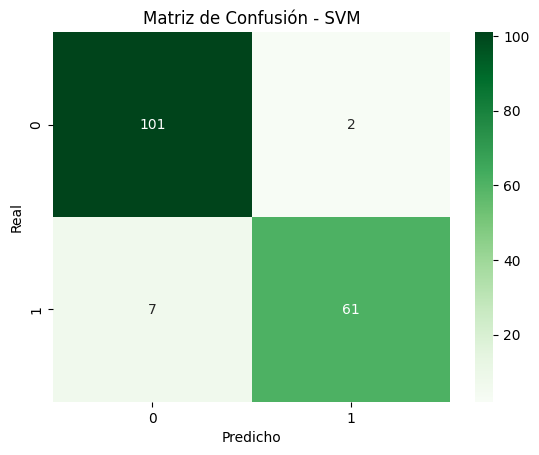

In [ ]:
# Matriz de confusión
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()